#### Mengakses Google Drive

In [54]:
#import

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Load Dataset

In [55]:
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Dataset/kalimat_clustering.csv')

#### Tampilkan Dataset

In [56]:
df

,Topik,Kalimat
0,Olahraga,Tim nasional sepak bola Indonesia berhasil lol...
1,Olahraga,Pemain bulu tangkis Indonesia memenangkan keju...
2,Olahraga,Lari maraton menjadi olahraga yang digemari ba...
3,Olahraga,Cristiano Ronaldo mencetak gol spektakuler dal...
4,Olahraga,Turnamen tenis Grand Slam tahun ini berlangsun...
...,...,...
112,Hiburan,Komik dan anime semakin populer di kalangan an...
113,Hiburan,Stand-up comedy semakin digemari oleh masyarakat.
114,Hiburan,Pameran seni kontemporer menarik banyak pengun...
115,Hiburan,Selebriti terkenal menghadiri acara penghargaa...


#### Tampilkan Distribusi Data

/tmp/ipykernel_6720/886108260.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Topik',data=df, palette='viridis')


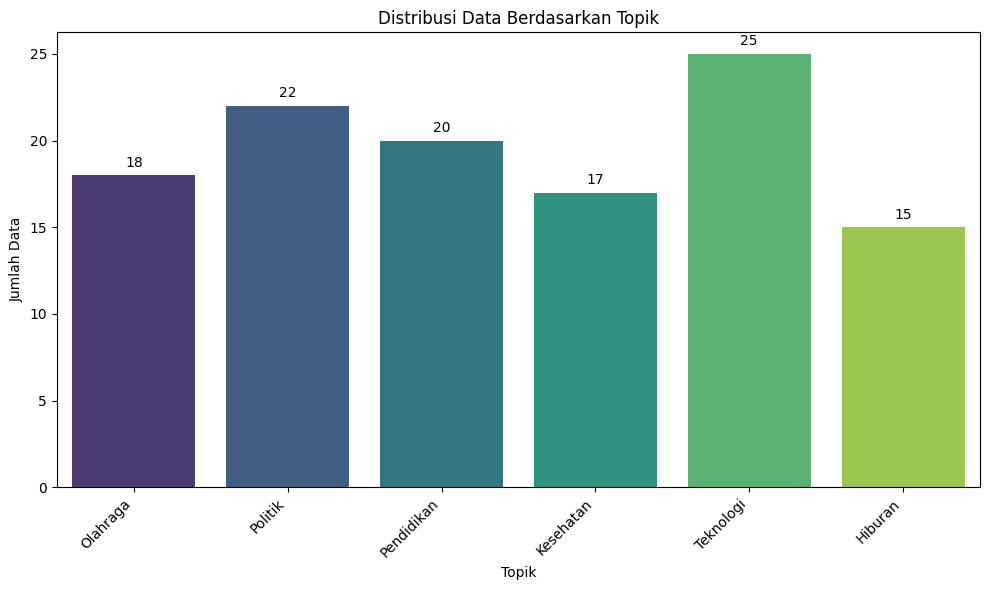

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# menghitung frekuensi setiap topik
topic_counts = df['Topik'].value_counts()

# membuat diagram batang
plt.figure(figsize=(10,6))
ax = sns.countplot(x='Topik',data=df, palette='viridis')

# menambahkan angka di atas bar
for p in ax.patches:
  ax.annotate(format(p.get_height(), '.0f'),
              (p.get_x() + p.get_width() / 2., p.get_height()),
              ha = 'center', va = 'center',
              xytext =(0, 9),
              textcoords='offset points')

plt.title('Distribusi Data Berdasarkan Topik')
plt.xlabel('Topik')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

#### Cleaning Kalimat

In [58]:
# Daftar kata sambung dalam bahasa Indonesia
kata_sambung = ['dan', 'untuk', 'atau', 'tetapi', 'melainkan', 'serta',
                'sedangkan', 'sementara', 'padahal', 'agar', 'sehingga',
                'sebab', 'karena', 'lalu', 'kemudian', 'walaupun', 'meskipun',
                'biarpun', 'sungguhpun', 'apabila', 'jika', 'kalau', 'jikalau',
                'seandainya', 'seolah', 'seakan', 'bakal', 'akan', 'hendak',
                'ingin', 'maupun', 'demi', 'untuk', 'guna', 'demi', 'terhadap',
                'atas', 'dengan', 'dari', 'di', 'ke', 'oleh', 'pada', 'seperti',
                'tentang', 'kepada', 'akan', 'kepada', 'daripada', 'sampai', 'supaya',
                'semakin', 'dalam', 'yang', 'menjadi', 'adalah', 'dapat']

def bersihkan_kalimat(kalimat):
  """
  Fungsi untuk membersihkan kalimat dari kata sambung.
  """
  kata_kata = kalimat.lower().split()
  kalimat_bersih =[kata for kata in kata_kata if kata not in kata_sambung]
  return ' '.join(kalimat_bersih)

# membuat kolom baru 'kalimat_clean' dengan hasil pembersihan
df['Kalimat_clean'] = df['Kalimat'].apply(bersihkan_kalimat)

# menampilkan dataframe dengan kolom kalimat_clean
df

,Topik,Kalimat,Kalimat_clean
0,Olahraga,Tim nasional sepak bola Indonesia berhasil lol...,tim nasional sepak bola indonesia berhasil lol...
1,Olahraga,Pemain bulu tangkis Indonesia memenangkan keju...,pemain bulu tangkis indonesia memenangkan keju...
2,Olahraga,Lari maraton menjadi olahraga yang digemari ba...,lari maraton olahraga digemari banyak orang.
3,Olahraga,Cristiano Ronaldo mencetak gol spektakuler dal...,cristiano ronaldo mencetak gol spektakuler per...
4,Olahraga,Turnamen tenis Grand Slam tahun ini berlangsun...,turnamen tenis grand slam tahun ini berlangsun...
...,...,...,...
112,Hiburan,Komik dan anime semakin populer di kalangan an...,komik anime populer kalangan anak muda.
113,Hiburan,Stand-up comedy semakin digemari oleh masyarakat.,stand-up comedy digemari masyarakat.
114,Hiburan,Pameran seni kontemporer menarik banyak pengun...,pameran seni kontemporer menarik banyak pengun...
115,Hiburan,Selebriti terkenal menghadiri acara penghargaa...,selebriti terkenal menghadiri acara penghargaa...


#### Tampilkan wordcloud

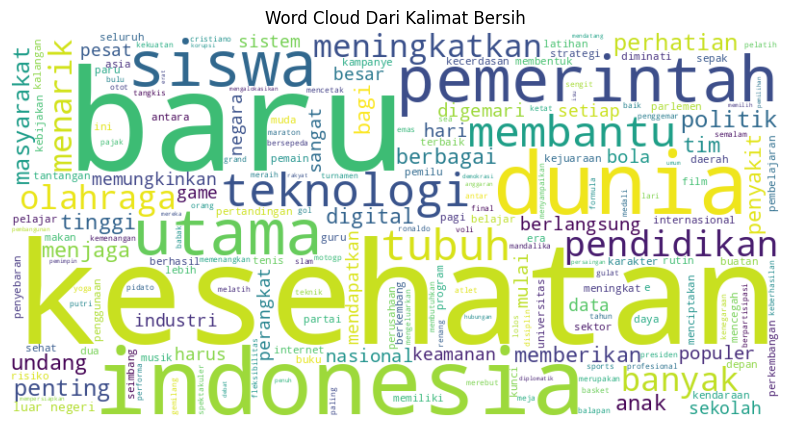

In [59]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# menggabungkan semua kalimat dalam kolom 'Kalimat_clean' menjadi satu teks
all_text = " ".join(df['Kalimat_clean'].astype(str))

# membuat objek wordcloud
wordcloud = WordCloud(width=800, height=400,background_color='white').generate(all_text)

# menampilkan wordcloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Dari Kalimat Bersih')
plt.show()

#### Tugas antara!
1. Jika wordcloud masih menampilkan kata tidak penting (seperti kata sambung) dengan
besaran visual yang masih dominan, maka tambahkan kata tersebut sebagai kata
yang harus dihapus pada block Cleaning Kalimat (array kata_sambung[])

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Daftar kata sambung (Cleaning Block)
kata_sambung = [
    'dan', 'untuk', 'atau', 'tetapi', 'melainkan', 'serta', 'sedangkan',
    'sementara', 'padahal', 'agar', 'sehingga', 'sebab', 'karena', 'lalu',
    'kemudian', 'walaupun', 'meskipun', 'biarpun', 'sungguhpun', 'apabila',
    'jika', 'kalau', 'jikalau', 'seandainya', 'seolah', 'seakan', 'bakal',
    'akan', 'hendak', 'ingin', 'maupun', 'demi', 'guna', 'terhadap', 'atas',
    'dengan', 'dari', 'di', 'ke', 'oleh', 'pada', 'seperti', 'tentang',
    'kepada', 'daripada', 'sampai', 'supaya', 'semakin', 'dalam', 'yang',
    'menjadi', 'adalah', 'dapat', 'ini', 'itu', 'ada', 'yaitu', 'yakni',
    'secara', 'saya', 'kami', 'kita', 'mereka', 'anda', 'dia', 'suatu',
    'bisa', 'sudah', 'telah', 'ia', 'juga', 'hal', 'bahwa', 'namun'
]

2. Buatkan wordcloud untuk masing-masing topik kalimat

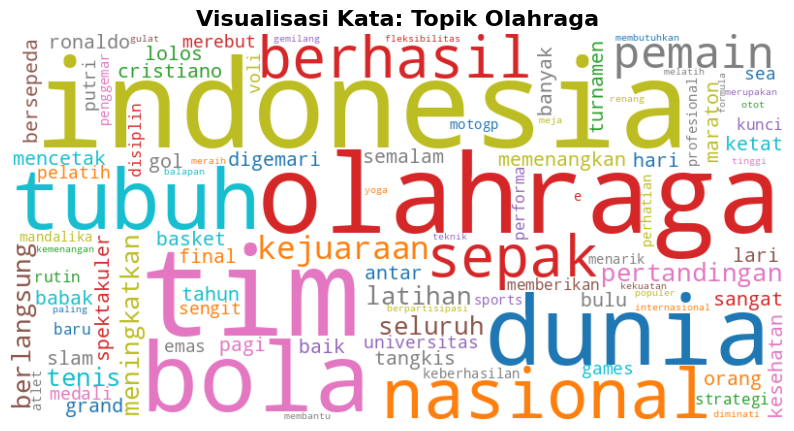

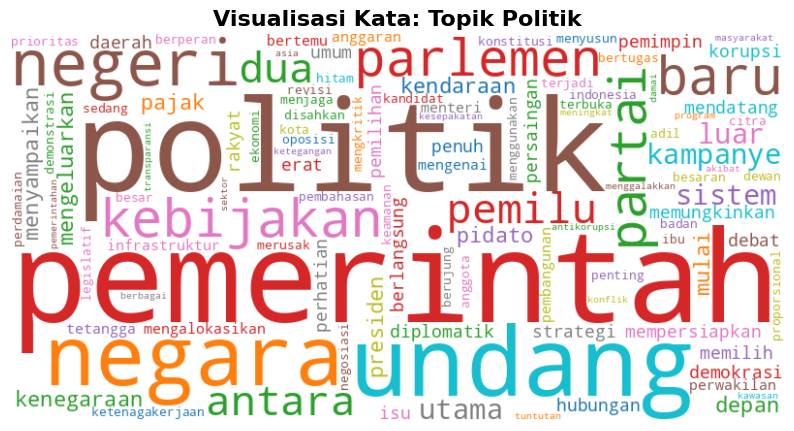

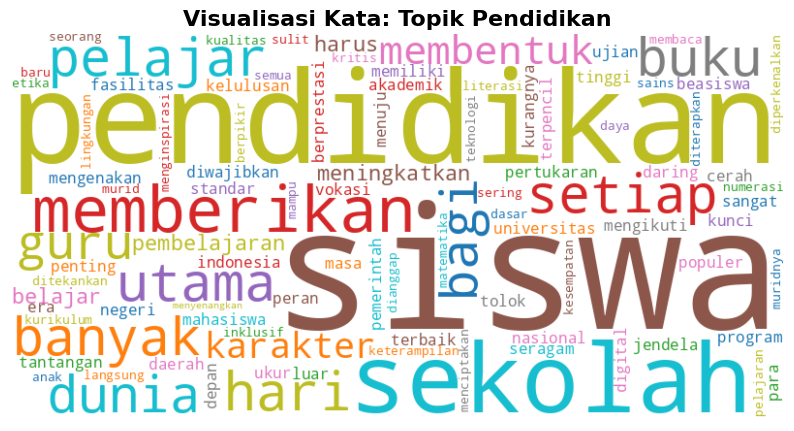

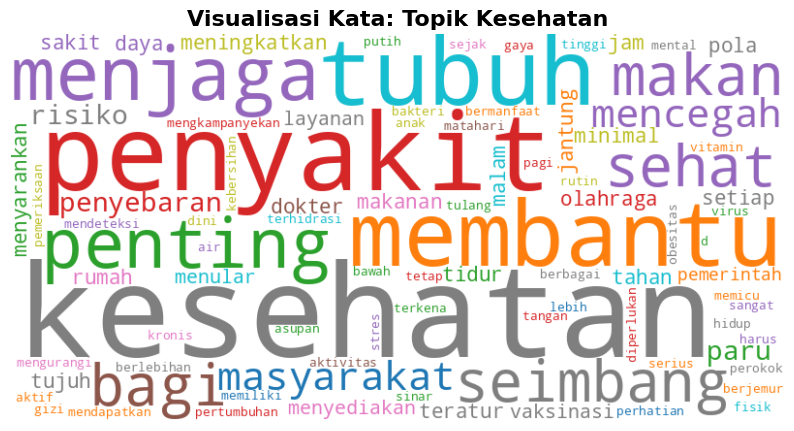

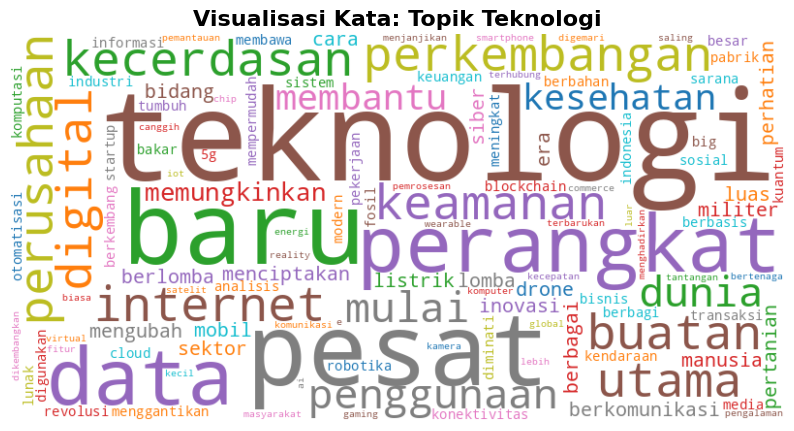

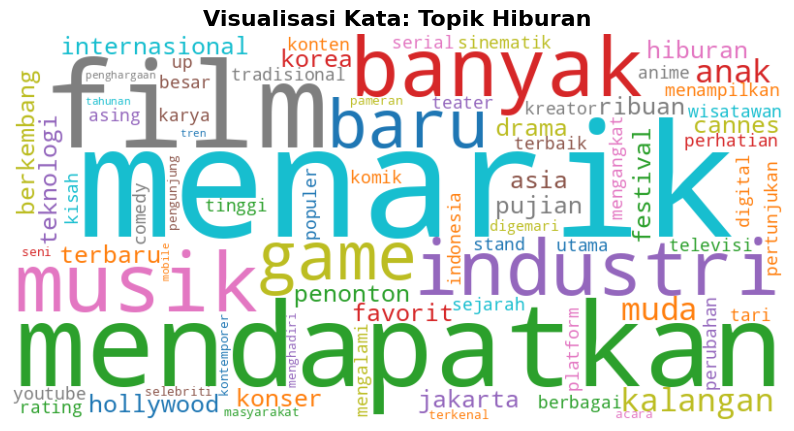

In [61]:
# 2. Ambil daftar topik unik yang ada di file (Olahraga, Teknologi, dll)
daftar_topik = df['Topik'].unique()

# 3. Loop untuk membuat wordcloud per topik
for topik in daftar_topik:
    # Filter kalimat berdasarkan topik saat ini
    teks_per_topik = " ".join(df[df['Topik'] == topik]['Kalimat'])

    # Inisialisasi WordCloud
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=set(kata_sambung), # Menghapus kata sambung
        colormap='tab10',            # Warna bervariasi
        min_font_size=10
    ).generate(teks_per_topik.lower()) # Kecilkan huruf agar cocok dengan stopwords

    # Tampilkan Visualisasi
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Visualisasi Kata: Topik {topik}", fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()

#### Tranformasi data teks ke frekuensi kata

In [62]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# inisialisasi CountVectorizer
vectorizer = CountVectorizer()

# melakukan transformasi pada kolom 'Kalimat_clean'
vectorized_data = vectorizer.fit_transform(df['Kalimat_clean'])

# membuat dataframe baru dari hasil transformasi
df_new = pd.DataFrame(vectorized_data.toarray(), columns=vectorizer.get_feature_names_out(), index=df.index)

# menampilkan dataframe baru
df_new

,5g,acara,adil,ai,air,akademik,akibat,aktif,aktivitas,anak,...,vaksinasi,virtual,virus,vitamin,vokasi,voli,wearable,wisatawan,yoga,youtube
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
113,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
114,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
115,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### K-means clustering

In [63]:
from sklearn.cluster import KMeans

# melakukan K-Means clustering dengan 6 cluster
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(df_new)

# menambahkan kolom 'Cluster' ke dataframe df_new
df_new['Cluster'] = kmeans.labels_

# menampilkan dataframe dengan kolom cluster
df_new

,5g,acara,adil,ai,air,akademik,akibat,aktif,aktivitas,anak,...,virtual,virus,vitamin,vokasi,voli,wearable,wisatawan,yoga,youtube,Cluster
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
113,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
114,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
115,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4


#### Analisis Purity clustering

In [64]:
# prompt: ambil df['topik'], ubah ke bentuk index, masukan ke df_new['topik'], lakukan analisis purity clustering

import pandas as pd
import numpy as np

# 1. Membuat salinan dataframe df_new untuk analisis kemurnian
df_purity = df_new.copy()

# 2. Mengambil kolom 'Topik' dari df dan memasukkannya ke df_purity
df_purity['Topik'] = df['Topik']

# 3. Membuat tabel kontingensi untuk melihat irisan antara 'Cluster' dan 'Topik'
contingency_table = pd.crosstab(df_purity['Cluster'], df_purity['Topik'])

# 4. Menghitung skor kemurnian per cluster (Sesuai Screenshot 141)
# Kita mengambil nilai maksimum dari setiap baris (topik dominan)
# lalu dibagi dengan total anggota di cluster tersebut
purity_per_cluster = contingency_table.max(axis=1) / contingency_table.sum(axis=1)

# 5. Menampilkan hasil
print("Skor Kemurnian Cluster:")
print(purity_per_cluster)

# 6. Menampilkan tabel kontingensi
print("\nTabel Kontingensi (Cluster vs Topik):")
print(contingency_table)

# 7. Mencari cluster dengan anggota topik yang paling dominan
for cluster in df_purity['Cluster'].unique():
    df_cluster = df_purity[df_purity['Cluster'] == cluster]
    topik_counts = df_cluster['Topik'].value_counts()

    if not topik_counts.empty:
        topik_dominan = topik_counts.idxmax()
        print(f"\nCluster {cluster}:")
        print(f"Topik paling dominan: {topik_dominan}")
        print(f"Jumlah anggota topik: {topik_counts[topik_dominan]}")

Skor Kemurnian Cluster:
Cluster
0    0.500000
1    0.375000
2    0.500000
3    0.714286
4    0.206186
5    1.000000
dtype: float64

Tabel Kontingensi (Cluster vs Topik):
Topik    Hiburan  Kesehatan  Olahraga  Pendidikan  Politik  Teknologi
Cluster                                                              
0              0          1         0           1        0          0
1              2          3         0           2        1          0
2              0          1         1           0        0          0
3              1          0         0           1        0          5
4             12         12        17          16       20         20
5              0          0         0           0        1          0

Cluster 4:
Topik paling dominan: Politik
Jumlah anggota topik: 20

Cluster 2:
Topik paling dominan: Olahraga
Jumlah anggota topik: 1

Cluster 5:
Topik paling dominan: Politik
Jumlah anggota topik: 1

Cluster 1:
Topik paling dominan: Kesehatan
Jumlah anggota topik: 3

C

#### Tugas Praktikum 2

#### clustering dengan bentuk transformasi (TF-IDF)

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Transformasi Data Teks menggunakan TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['Kalimat_clean'])

#### clustering dengan mencoba beberapa jumlah clustering menjadi 8, 10 dan 12

In [66]:
daftar_n_clusters = [8, 10, 12]

# menyimpan ringkasan hasil untuk laporan
ringkasan_purity = []

#### analisis purity untuk setiap percobaan

In [67]:
print("--- ANALISIS PURITY CLUSTERING (TF-IDF) ---")

for n in daftar_n_clusters:
    # Melakukan Clustering
    kmeans = KMeans(n_clusters=n, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_tfidf)

    # Menghitung Purity per Cluster
    # Membuat tabel kontingensi antara Cluster baru dan Topik asli
    temp_contingency = pd.crosstab(cluster_labels, df['Topik'])

    # Skor kemurnian per cluster
    purity_per_cluster = temp_contingency.max(axis=1) / temp_contingency.sum(axis=1)

    # Skor kemurnian total (Global Purity)
    total_purity = temp_contingency.max(axis=1).sum() / temp_contingency.values.sum()

    # Simpan hasil untuk ringkasan
    ringkasan_purity.append({'Jumlah Cluster': n, 'Total Purity': total_purity})

    # Menampilkan Hasil per Percobaan
    print(f"\n Percobaan dengan n_clusters = {n}")
    print(f"Total Purity: {total_purity:.4f}")
    print("Purity per Cluster:")
    print(purity_per_cluster)
    print("-" * 40)

# Menampilkan Tabel Ringkasan untuk Laporan
print("\n--- RINGKASAN UNTUK LAPORAN ---")
df_hasil = pd.DataFrame(ringkasan_purity)
print(df_hasil)

--- ANALISIS PURITY CLUSTERING (TF-IDF) ---

 Percobaan dengan n_clusters = 8
Total Purity: 0.3419
Purity per Cluster:
row_0
0    0.500000
1    0.230769
2    0.333333
3    0.250000
4    0.400000
5    0.454545
6    0.500000
7    0.625000
dtype: float64
----------------------------------------

 Percobaan dengan n_clusters = 10
Total Purity: 0.4274
Purity per Cluster:
row_0
0    0.625000
1    0.300000
2    0.500000
3    0.400000
4    0.309524
5    0.428571
6    0.857143
7    1.000000
8    0.357143
9    0.333333
dtype: float64
----------------------------------------

 Percobaan dengan n_clusters = 12
Total Purity: 0.4701
Purity per Cluster:
row_0
0     0.250000
1     0.636364
2     0.250000
3     0.600000
4     0.727273
5     0.600000
6     0.333333
7     1.000000
8     0.500000
9     0.555556
10    0.857143
11    0.375000
dtype: float64
----------------------------------------

--- RINGKASAN UNTUK LAPORAN ---
   Jumlah Cluster  Total Purity
0               8      0.341880
1             

#### Tugas Pertemuan 2

1. Buatlah dokumentasi kajian literatur dan contoh perhitungan manual:

*   Term Frequency\
TF mengukur seberapa sering sebuah kata muncul dalam satu dokumen (kalimat). Rumus Sederhana: $TF(t, d) = \text{Jumlah kemunculan kata } t \text{ dalam dokumen } d$. Contoh: Kalimat "kucing makan ikan". TF untuk kata "kucing" adalah 1.

*   TF-IDF\
TF-IDF digunakan untuk mengetahui seberapa penting sebuah kata dalam kumpulan dokumen.Rumus: $TF\text{-}IDF = TF \times IDF$Di mana $IDF = \log\left(\frac{\text{Total Dokumen}}{\text{Dokumen yang mengandung kata } t}\right)$.Logika: Jika kata "yang" muncul di semua dokumen, nilai IDF-nya kecil (dianggap tidak penting). Jika kata "Kecerdasan" hanya muncul di 1 dokumen, nilainya besar (dianggap kata kunci penting).

*   Purity Score\
Jelaskan coding ini:


In [68]:
def purity_score(y_true, y_pred):
    contingency_matrix = pd.crosstab(y_true, y_pred)
    return np.sum(np.amax(contingency_matrix.values, axis=0)) / np.sum(contingency_matrix.values)

*   pd.crosstab: Membuat tabel matriks yang memetakan jumlah irisan antara label asli (y_true) dengan hasil cluster (y_pred)
*   np.amax(..., axis=0): Mengambil jumlah anggota terbanyak (mayoritas) dari setiap cluster.
*   np.sum(...): Menjumlahkan seluruh anggota mayoritas tersebut.
*   / np.sum(...): Dibagi dengan total seluruh data untuk mendapatkan persentase kemurnian akhir.





2. Pada praktikum ini, data yang digunakan adalah data dummy hasil generate chat-gpt.
buatlah data original yang diambil dari berbagai berita dari berbagai topik yang diambil
dari JUDUL BERITA di situs detik.com. Kumpulkan sebanyak 10 topik, dengan
masing-masing topik sebanyak 20 sd 30 kalimat judul berita. (tugas bersama 1 kelas)

In [69]:
import pandas as pd
import string
import numpy as np
from google.colab import drive

# 1. Mounting Drive
drive.mount('/content/drive', force_remount=True)

# 2. Load Dataset dengan separator titik koma (;)
file_path = '/content/drive/My Drive/Colab Notebooks/Dataset/Data_Berita_Detik.csv'

# Menggunakan sep=';' karena data kamu terdeteksi menggunakan titik koma
df = pd.read_csv(file_path, sep=';', on_bad_lines='skip', engine='python')

# Deteksi kolom secara otomatis
if 'Kalimat' in df.columns:
    kolom_target = 'Kalimat'
elif 'Judul Berita' in df.columns:
    kolom_target = 'Judul Berita'
else:
    # Jika masih gabung, kita ambil kolom yang mengandung kata 'Kalimat'
    kolom_target = [c for c in df.columns if 'Kalimat' in c][0]

print(f"Berhasil memuat data. Menggunakan kolom: '{kolom_target}'")

# 3. Cleaning Data (Daftar kata_sambung sesuai modul)
kata_sambung = ['dan', 'untuk', 'atau', 'tetapi', 'melainkan', 'serta', 'sedangkan', 'sementara',
                'padahal', 'agar', 'sehingga', 'sebab', 'karena', 'lalu', 'kemudian', 'walaupun',
                'meskipun', 'biarpun', 'sungguhpun', 'apabila', 'jika', 'kalau', 'jikalau',
                'seandainya', 'seolah', 'seakan', 'bakal', 'akan', 'hendak', 'ingin', 'maupun',
                'demi', 'guna', 'terhadap', 'atas', 'with', 'dengan', 'dari', 'di', 'ke', 'oleh',
                'pada', 'seperti', 'tentang', 'kepada', 'daripada', 'sampai', 'supaya', 'semakin',
                'dalam', 'yang', 'menjadi', 'adalah', 'dapat']

def bersihkan_kalimat(kalimat):
    # Case folding (kecilkan huruf)
    kalimat = str(kalimat).lower()
    # Hapus tanda baca
    kalimat = kalimat.translate(str.maketrans('', '', string.punctuation))
    # Filter kata sambung
    kata_kata = kalimat.split()
    kalimat_bersih = [kata for kata in kata_kata if kata not in kata_sambung]
    return " ".join(kalimat_bersih)

# Membuat kolom baru 'Kalimat_clean' [cite: 138]
df['Kalimat_clean'] = df[kolom_target].apply(bersihkan_kalimat)

print("Cleaning Selesai!")
df[['Topik', 'Kalimat_clean']].head()

Mounted at /content/drive
Berhasil memuat data. Menggunakan kolom: 'Kalimat'
Cleaning Selesai!


,Topik,Kalimat_clean
0,News,banjir rendam 16 desa grobogan jateng 3176 kel...
1,News,pasukan perdamaian kembali jadi korban seranga...
2,News,bandung hujan angin hingga puluhan pohon tumba...
3,News,2560 warga kunjungi monas saat libur jumat agung
4,News,macan tutul terjerat dekat permukiman warga bo...


3. Lakukan analisis clustering pada tugas pertemuan 2, buat presentasinya.

#### Visualisasi

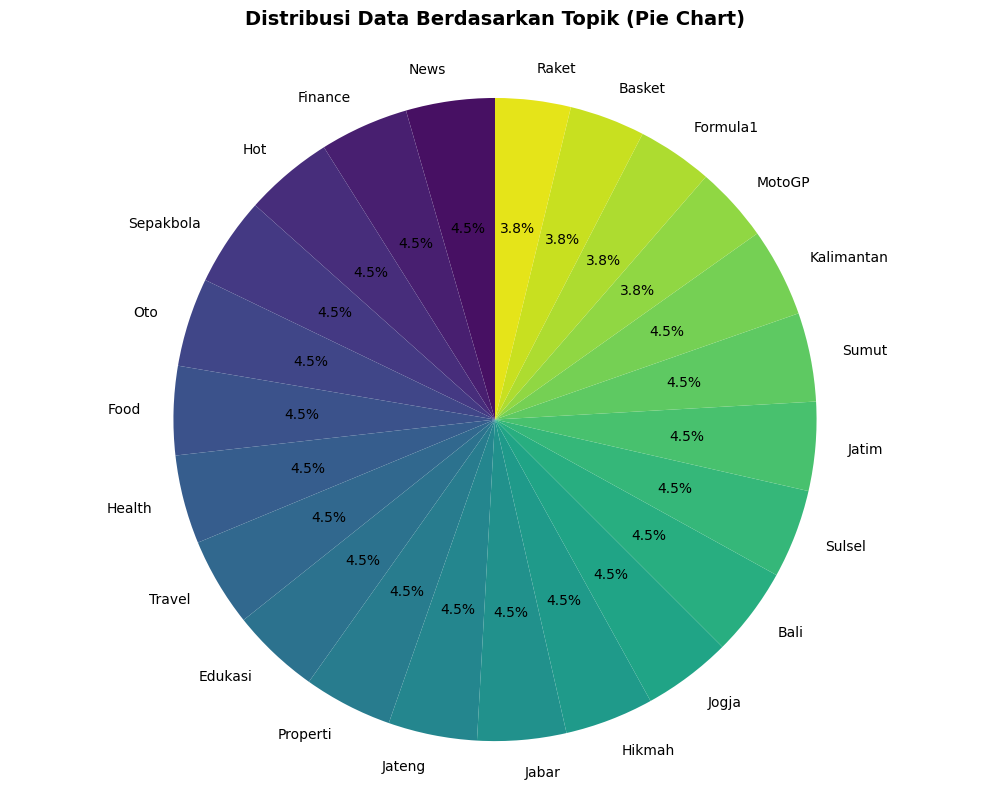

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung frekuensi setiap topik
topic_counts = df['Topik'].value_counts()

# Membuat diagram lingkaran (pie chart)
plt.figure(figsize=(10, 8))
plt.pie(topic_counts.values, labels=topic_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(topic_counts)))

# Menambahkan pad pada title untuk memberikan jarak (enter)
plt.title('Distribusi Data Berdasarkan Topik (Pie Chart)', pad=30, fontsize=14, fontweight='bold')
plt.ylabel('') # Hapus label y untuk pie chart
plt.axis('equal') # Memastikan pie chart berbentuk lingkaran
plt.tight_layout()
plt.show()

#### WordCloud

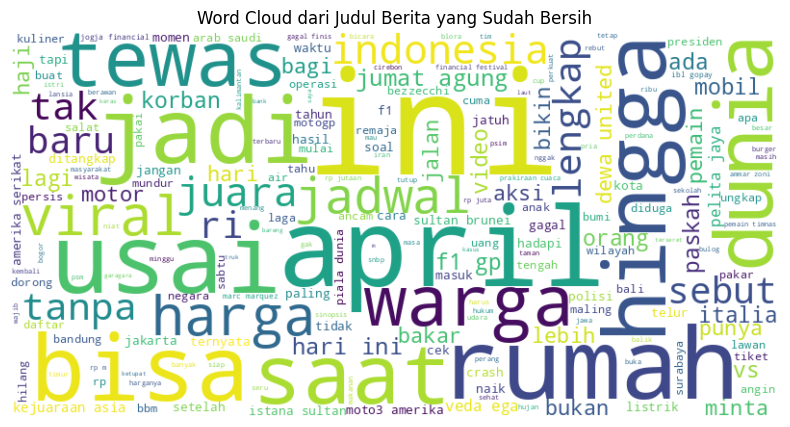

In [71]:
from wordcloud import WordCloud

# Menggabungkan semua kalimat bersih menjadi satu teks besar
all_text = " ".join(df['Kalimat_clean'].astype(str))

# Membuat objek WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Menampilkan wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud dari Judul Berita yang Sudah Bersih')
plt.show()

#### Transformasi Data (TF-IDF)

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TfidfVectorizer
vectorizer = TfidfVectorizer()

# Melakukan transformasi pada kolom yang sudah bersih
vectorized_data = vectorizer.fit_transform(df['Kalimat_clean'])

# Membuat dataframe baru hasil transformasi agar bisa diproses K-Means
df_new = pd.DataFrame(vectorized_data.toarray(), columns=vectorizer.get_feature_names_out(), index=df.index)

df_new

,00,01,10,100,11,12,120,127,13,14,...,yesus,yogyakarta,yuk,yuki,yunus,zaman,zodiak,zon,zoni,zonk
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
444,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
445,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### K-Means Clustering

In [73]:
from sklearn.cluster import KMeans

# Contoh melakukan clustering dengan 5 cluster
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(df_new)

# Menambahkan label cluster ke dataframe
df_new['Cluster'] = kmeans.labels_

df_new

,00,01,10,100,11,12,120,127,13,14,...,yogyakarta,yuk,yuki,yunus,zaman,zodiak,zon,zoni,zonk,Cluster
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
444,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
445,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


#### Purity

In [74]:
import numpy as np

def analisis_purity_detail_modul(y_true, y_pred):
    # 1. Membuat tabel kontingensi (Baris: Topik Asli, Kolom: Cluster)
    contingency_matrix = pd.crosstab(y_true, y_pred)

    # 2. Menghitung Skor Purity Keseluruhan
    purity_total = np.sum(np.amax(contingency_matrix.values, axis=0)) / np.sum(contingency_matrix.values)

    print("="*60)
    print(f"HASIL ANALISIS PURITY DETAIL (K = {n_clusters})")
    print("="*60)

    # 3. Menampilkan rincian per cluster seperti di halaman 7 modul
    for cluster_num in sorted(contingency_matrix.columns):
        # Ambil data untuk kolom cluster ini
        cluster_column = contingency_matrix[cluster_num]

        # Cari topik yang paling banyak muncul di cluster ini
        topik_dominan = cluster_column.idxmax()
        jumlah_anggota = cluster_column.max()
        total_data_cluster = cluster_column.sum()

        print(f"\nCluster {cluster_num}:")
        print(f"  Topik paling dominan : {topik_dominan}")
        print(f"  Jumlah anggota topik : {jumlah_anggota}")
        print(f"  Total data di cluster: {total_data_cluster}")
        print(f"  Persentase Kemurnian : {jumlah_anggota/total_data_cluster:.2%}")

    print("\n" + "="*60)
    print(f"TOTAL SKOR PURITY KESELURUHAN: {purity_total:.4f}")
    print("="*60)

# EKSEKUSI: Ambil 'Topik' dari df asli dan 'Cluster' dari df_new hasil K-Means kamu
analisis_purity_detail_modul(df['Topik'], df_new['Cluster'])

HASIL ANALISIS PURITY DETAIL (K = 5)

Cluster 0:
  Topik paling dominan : Food
  Jumlah anggota topik : 8
  Total data di cluster: 55
  Persentase Kemurnian : 14.55%

Cluster 1:
  Topik paling dominan : Hikmah
  Jumlah anggota topik : 19
  Total data di cluster: 289
  Persentase Kemurnian : 6.57%

Cluster 2:
  Topik paling dominan : Properti
  Jumlah anggota topik : 6
  Total data di cluster: 35
  Persentase Kemurnian : 17.14%

Cluster 3:
  Topik paling dominan : MotoGP
  Jumlah anggota topik : 9
  Total data di cluster: 9
  Persentase Kemurnian : 100.00%

Cluster 4:
  Topik paling dominan : Raket
  Jumlah anggota topik : 11
  Total data di cluster: 60
  Persentase Kemurnian : 18.33%

TOTAL SKOR PURITY KESELURUHAN: 0.1183


#### Pengecekan Purity Sesuai Dengan Cluster

In [75]:
# 1. Kita buat salinan data sementara tanpa kolom 'Cluster' agar
#    bisa diuji untuk 8, 10, dan 12 tanpa merusak tabel asli Anda
X_sementara = df_new.drop(columns=['Cluster'], errors='ignore')

# 2. Siapkan dictionary untuk menampung hasil prediksi sementara
dict_prediksi = {}
list_k = [8, 10, 12]

print("Menyiapkan laporan Purity, mohon tunggu sebentar...\n")

# 3. Hitung K-Means hanya untuk keperluan laporan
for k in list_k:
    # Menghitung hitung sementara, tapi TIDAK dimasukkan ke df_new
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init='auto')
    dict_prediksi[k] = kmeans_temp.fit_predict(X_sementara)

# 4. Cetak laporan - Incorporate the purity analysis logic here
print("--- ANALISIS PURITY CLUSTERING (TF-IDF - Data Baru) ---")

ringkasan_purity_new_data = [] # Untuk menyimpan ringkasan hasil

for n in list_k: # Iterasi melalui setiap nilai k
    cluster_labels = dict_prediksi[n] # Ambil label cluster untuk k saat ini

    # Menghitung Purity per Cluster
    # Membuat tabel kontingensi antara Cluster baru dan Topik asli
    temp_contingency = pd.crosstab(cluster_labels, df['Topik'])

    # Skor kemurnian per cluster
    # Dapatkan nilai maksimum dari setiap baris (klaster) dan dibagi dengan jumlah total anggota di klaster tersebut
    purity_per_cluster = temp_contingency.max(axis=1) / temp_contingency.sum(axis=1)

    # Skor kemurnian total (Global Purity)
    # Jumlahkan nilai maksimum dari setiap baris (topik dominan per klaster) dan dibagi dengan total seluruh data
    total_purity = temp_contingency.max(axis=1).sum() / temp_contingency.values.sum()

    # Simpan hasil untuk ringkasan
    ringkasan_purity_new_data.append({'Jumlah Cluster': n, 'Total Purity': total_purity})

    # Menampilkan Hasil per Percobaan
    print(f"\n Percobaan dengan n_clusters = {n}")
    print(f"Total Purity: {total_purity:.4f}")
    print("Purity per Cluster:")
    print(purity_per_cluster)
    print("-" * 40)

# Menampilkan Tabel Ringkasan untuk Laporan
print("\n--- RINGKASAN UNTUK LAPORAN (Data Baru) ---")
df_hasil_new_data = pd.DataFrame(ringkasan_purity_new_data)
print(df_hasil_new_data)

Menyiapkan laporan Purity, mohon tunggu sebentar...

--- ANALISIS PURITY CLUSTERING (TF-IDF - Data Baru) ---

 Percobaan dengan n_clusters = 8
Total Purity: 0.1562
Purity per Cluster:
row_0
0    0.170213
1    0.370370
2    0.150000
3    0.220000
4    0.166667
5    0.230769
6    0.071749
7    0.692308
dtype: float64
----------------------------------------

 Percobaan dengan n_clusters = 10
Total Purity: 0.1674
Purity per Cluster:
row_0
0    0.228571
1    0.370370
2    0.150000
3    0.224490
4    0.170732
5    0.181818
6    0.073529
7    0.692308
8    0.208333
9    0.230769
dtype: float64
----------------------------------------

 Percobaan dengan n_clusters = 12
Total Purity: 0.2121
Purity per Cluster:
row_0
0     0.242424
1     0.384615
2     0.166667
3     0.275000
4     0.241379
5     0.200000
6     0.076087
7     0.692308
8     0.208333
9     0.250000
10    0.205882
11    0.933333
dtype: float64
----------------------------------------

--- RINGKASAN UNTUK LAPORAN (Data Baru) ---
 